In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
dataset = pd.read_csv("advertising_and_sales_clean.csv")
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

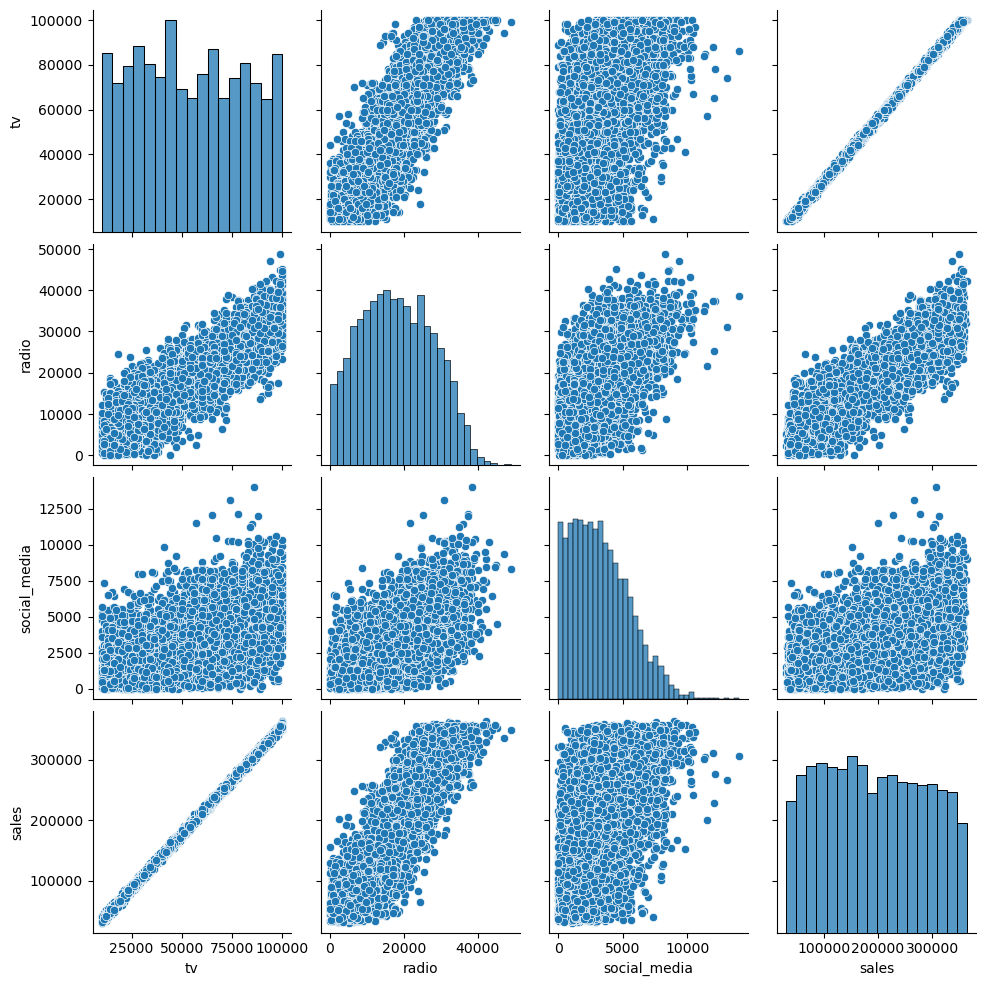

In [154]:
sns.pairplot(dataset)
plt.show()

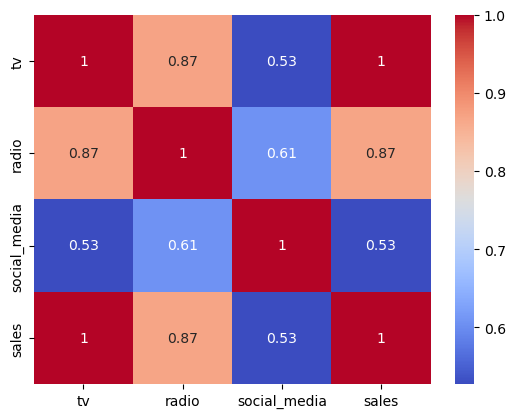

In [155]:
numeric_df = dataset.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix,annot=True,cmap = "coolwarm")
plt.show()

In [156]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [157]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Linear Regressor

In [158]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [159]:
y_pred = regressor.predict(X_test)

In [160]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error 
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R-Squared:",r2)

MAE: 2363.429883615831
RMSE: 2971.2148156729795
R-Squared: 0.9989886274617412


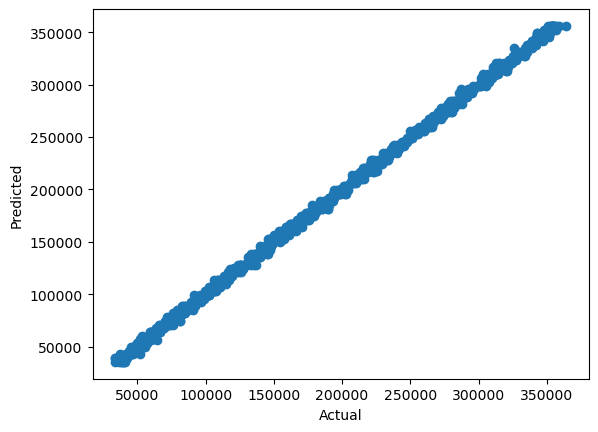

In [161]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Decision Tree Regressor

In [162]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [163]:
y_pred = regressor.predict(X_test)

In [164]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error 
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R-Squared:",r2)

MAE: 3385.4547912087914
RMSE: 4184.249575963137
R-Squared: 0.9979942434702385


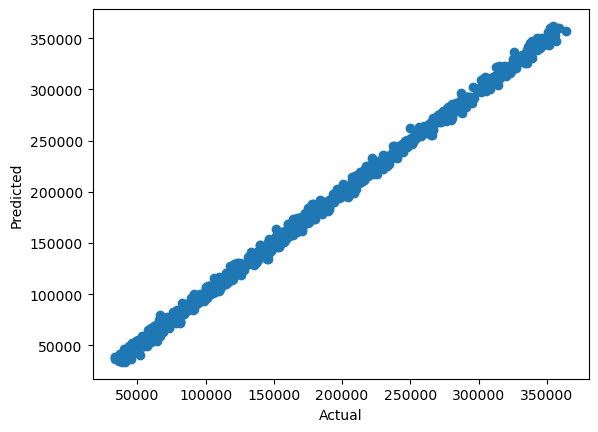

In [165]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Random Forest Regressor

In [166]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X, y)

RandomForestRegressor(n_estimators=10, random_state=0)

In [167]:
y_pred = regressor.predict(X_test)

In [168]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error 
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R-Squared:",r2)

MAE: 1056.3021945054966
RMSE: 1422.009037332991
R-Squared: 0.9997683417527418


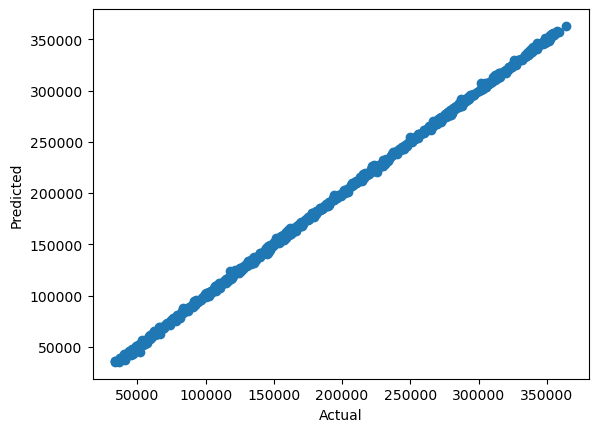

In [169]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## SVR

In [170]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [171]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

params = [{
    "kernel" : ["linear"],
    "C" : [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5]
},
{
    "kernel" : ["poly"],
    "degree" : [1,2,3,4],
    "gamma" : ["scale","auto"],
    "C": [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5]
},
{
    "kernel" : ["rbf", "sigmoid"],
    "gamma" : ["scale","auto"],
    "C": [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5]
}
]

grid = GridSearchCV(
    SVR(),
    params,
    scoring = "r2",
    cv = 10,
    n_jobs=-1
)


grid.fit(X_train,y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Params: {'C': 1000, 'epsilon': 0.1, 'kernel': 'linear'}
Best R2 Score: 0.9989805834057904


In [172]:
y_pred = best_model.predict(X_test)

In [173]:
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error 
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R-Squared:",r2)

MAE: 2372.369371786386
RMSE: 2976.67667087324
R-Squared: 0.9989849057196674


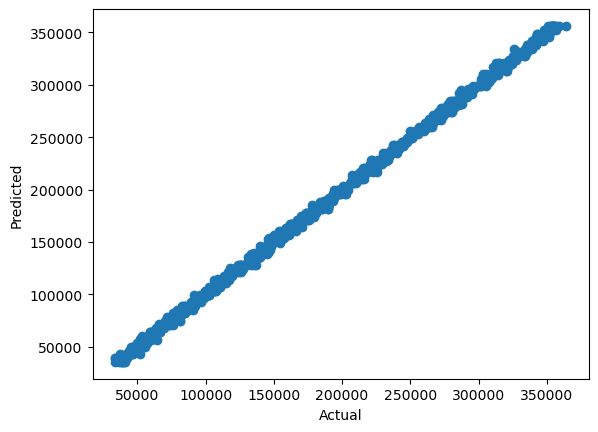

In [174]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()